# NB-R08 — Ablation Studies
**Addresses:** R3.4

**Reviewer 3 comment:** "Ablation studies are needed to show the contributions of all the components of the stacked ensemble, including the self-attention of the BiLSTM."

**Ablations performed:**
1. Each base learner alone (XGB, LGB, RF, CB, BiLSTM)
2. Stacking without BiLSTM (tree models only)
3. BiLSTM without self-attention (mean pooling instead)
4. Full stacking ensemble (baseline for comparison)

All evaluated on the same held-out test set under High-VIX and Low-VIX regimes.

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

PROJ    = Path(r'F:\MLSAPU\PhD-SPPU\India-VIX-Major-Revision')
PROC    = PROJ / 'data' / 'processed'
RESULTS = PROJ / 'results'
PLOTS   = PROJ / 'plots'
MODELS  = PROJ / 'models'

with open(PROC / 'feature_cols.json') as f:
    FEATURE_COLS = json.load(f)

SEED       = 42
SEQ_LEN    = 20
HIDDEN     = 64
DROPOUT    = 0.2

train = pd.read_csv(PROC / 'train.csv', parse_dates=['date'])
val   = pd.read_csv(PROC / 'val.csv',   parse_dates=['date'])
test  = pd.read_csv(PROC / 'test_predictions.csv', parse_dates=['date'])

X_train = train[FEATURE_COLS].values;  y_train = train['dir_21d'].values
X_val   = val[FEATURE_COLS].values;    y_val   = val['dir_21d'].values
X_test  = test[FEATURE_COLS].values;   y_test  = test['dir_21d'].values
regime  = test['regime_fixed'].values

# Load pre-trained base models
xgb_model = joblib.load(MODELS / 'xgb_model.joblib')
lgb_model = joblib.load(MODELS / 'lgb_model.joblib')
rf_model  = joblib.load(MODELS / 'rf_model.joblib')
cb_model  = joblib.load(MODELS / 'cb_model.joblib')
meta      = joblib.load(MODELS / 'meta_learner.joblib')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Models loaded.')

Device: cpu
Models loaded.


## 1. BiLSTM Without Self-Attention (Mean Pooling)

In [2]:
class BiLSTMMeanPool(nn.Module):
    """BiLSTM with mean pooling instead of self-attention (ablation)."""
    def __init__(self, input_size, hidden_size, dropout):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        ctx    = out.mean(dim=1)   # mean pooling instead of attention
        ctx    = self.dropout(ctx)
        return self.fc(ctx).squeeze(-1)

def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i]); ys.append(y[i])
    return np.array(Xs), np.array(ys)

Xtr_seq, ytr_seq = make_sequences(X_train, y_train, SEQ_LEN)
Xva_seq, yva_seq = make_sequences(X_val,   y_val,   SEQ_LEN)
Xte_seq, yte_seq = make_sequences(X_test,  y_test,  SEQ_LEN)

def train_bilstm(model_cls, Xtr, ytr, Xva, yva, max_epochs=50, patience=8, lr=1e-3, batch=64):
    torch.manual_seed(SEED)
    model = model_cls(len(FEATURE_COLS), HIDDEN, DROPOUT).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    tr_ds = DataLoader(TensorDataset(torch.tensor(Xtr, dtype=torch.float32),
                                      torch.tensor(ytr, dtype=torch.float32)), batch_size=batch, shuffle=False)
    va_ds = DataLoader(TensorDataset(torch.tensor(Xva, dtype=torch.float32),
                                      torch.tensor(yva, dtype=torch.float32)), batch_size=batch, shuffle=False)
    best_loss = float('inf'); cnt = 0; best_state = None
    for ep in range(max_epochs):
        model.train()
        for Xb, yb in tr_ds:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad(); loss_fn(model(Xb), yb).backward(); opt.step()
        model.eval(); vl = []
        with torch.no_grad():
            for Xb, yb in va_ds:
                vl.append(loss_fn(model(Xb.to(device)), yb.to(device)).item())
        val_loss = np.mean(vl)
        if val_loss < best_loss:
            best_loss = val_loss; cnt = 0; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            cnt += 1
            if cnt >= patience: break
    model.load_state_dict(best_state)
    return model, best_loss

print('Training BiLSTM without self-attention (mean pooling)...')
bilstm_nosa, _ = train_bilstm(BiLSTMMeanPool, Xtr_seq, ytr_seq, Xva_seq, yva_seq)
print('Done.')

Training BiLSTM without self-attention (mean pooling)...
Done.


## 2. Get Predictions for All Ablation Configurations

In [4]:
def get_probs(model, X_seq):
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(torch.tensor(X_seq, dtype=torch.float32).to(device))).cpu().numpy()

# Align to test rows with BiLSTM offset (SEQ_LEN rows dropped at start)
n_seq = len(Xte_seq)
test_aligned = test.iloc[-n_seq:].copy()
y_test_a = yte_seq
regime_a = test_aligned['regime_fixed'].values

xgb_p_a  = xgb_model.predict_proba(X_test[-n_seq:])[:, 1]
lgb_p_a  = lgb_model.predict_proba(X_test[-n_seq:])[:, 1]
rf_p_a   = rf_model.predict_proba(X_test[-n_seq:])[:, 1]
cb_p_a   = cb_model.predict_proba(X_test[-n_seq:])[:, 1]

# Optional import; notebook can proceed with inline class below
try:
    from NB_R03_utils import BiLSTMClassifier
    print('Loaded BiLSTMClassifier from NB_R03_utils.')
except ModuleNotFoundError:
    print('NB_R03_utils not found; using inline BiLSTM definition below.')

NB_R03_utils not found; using inline BiLSTM definition below.


In [5]:
# Redefine BiLSTM with attention inline (no import dependency)
class SelfAttention(nn.Module):
    def __init__(self, h): super().__init__(); self.attn = nn.Linear(h*2, 1)
    def forward(self, x): return (x * torch.softmax(self.attn(x), dim=1)).sum(dim=1)

class BiLSTMAttn(nn.Module):
    def __init__(self, input_size, hidden_size, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.attn = SelfAttention(hidden_size)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size*2, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(self.attn(out))).squeeze(-1)

# Load best BiLSTM with attention
bilstm_attn = BiLSTMAttn(len(FEATURE_COLS), HIDDEN, DROPOUT).to(device)
bilstm_attn.load_state_dict(torch.load(MODELS / 'bilstm_best.pt', map_location=device))

bilstm_attn_probs = get_probs(bilstm_attn, Xte_seq)
bilstm_nosa_probs = get_probs(bilstm_nosa, Xte_seq)

# Stacking: tree models only (no BiLSTM)
meta_trees_only = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
Xva_trees = np.column_stack([
    xgb_model.predict_proba(X_val[-len(Xva_seq):])[:, 1],
    lgb_model.predict_proba(X_val[-len(Xva_seq):])[:, 1],
    rf_model.predict_proba(X_val[-len(Xva_seq):])[:, 1],
    cb_model.predict_proba(X_val[-len(Xva_seq):])[:, 1],
])
meta_trees_only.fit(Xva_trees, y_val[-len(Xva_seq):])
stack_trees_probs = meta_trees_only.predict_proba(
    np.column_stack([xgb_p_a, lgb_p_a, rf_p_a, cb_p_a]))[:, 1]

# Full stack probs (from NB-R03)
stack_full_probs = test_aligned['stack_prob'].values

print('All ablation predictions ready.')

All ablation predictions ready.


## 3. Ablation Results Table

In [6]:
def ablation_row(name, probs, y_true, regime):
    preds = (probs >= 0.5).astype(int)
    rows = []
    for reg in ['High-VIX', 'Low-VIX', 'Overall']:
        mask = np.ones(len(y_true), dtype=bool) if reg == 'Overall' else regime == reg
        if mask.sum() < 2: continue
        yt = y_true[mask]; yp = preds[mask]; ypr = probs[mask]
        rows.append({
            'Configuration': name, 'Regime': reg, 'N': int(mask.sum()),
            'Accuracy (%)': round(accuracy_score(yt, yp)*100, 1),
            'F1 (%)': round(f1_score(yt, yp, zero_division=0)*100, 1),
            'ROC-AUC': round(roc_auc_score(yt, ypr), 4) if len(np.unique(yt)) > 1 else 'N/A'
        })
    return rows

ablation_rows = []
for name, probs in [
    ('XGBoost only',          xgb_p_a),
    ('LightGBM only',         lgb_p_a),
    ('Random Forest only',    rf_p_a),
    ('CatBoost only',         cb_p_a),
    ('BiLSTM+Attention only', bilstm_attn_probs),
    ('BiLSTM (no attention)', bilstm_nosa_probs),
    ('Stack (trees only)',     stack_trees_probs),
    ('Stack (full)',           stack_full_probs),
]:
    ablation_rows.extend(ablation_row(name, probs, y_test_a, regime_a))

abl_df = pd.DataFrame(ablation_rows)
print(abl_df.to_string(index=False))
abl_df.to_csv(RESULTS / 'ablation_results.csv', index=False)
print('\nAblation results saved.')

        Configuration   Regime   N  Accuracy (%)  F1 (%) ROC-AUC
         XGBoost only High-VIX   8           0.0     0.0     N/A
         XGBoost only  Low-VIX 228          45.2    56.4  0.4528
         XGBoost only  Overall 236          43.6    54.9  0.4443
        LightGBM only High-VIX   8           0.0     0.0     N/A
        LightGBM only  Low-VIX 228          48.7    59.5  0.4728
        LightGBM only  Overall 236          47.0    57.9  0.4641
   Random Forest only High-VIX   8          62.5    76.9     N/A
   Random Forest only  Low-VIX 228          48.7    55.5  0.4719
   Random Forest only  Overall 236          49.2    56.5  0.4741
        CatBoost only High-VIX   8           0.0     0.0     N/A
        CatBoost only  Low-VIX 228          49.6    51.1  0.5146
        CatBoost only  Overall 236          47.9    49.4  0.4918
BiLSTM+Attention only High-VIX   8           0.0     0.0     N/A
BiLSTM+Attention only  Low-VIX 228          51.8    51.8  0.4965
BiLSTM+Attention only  Ov

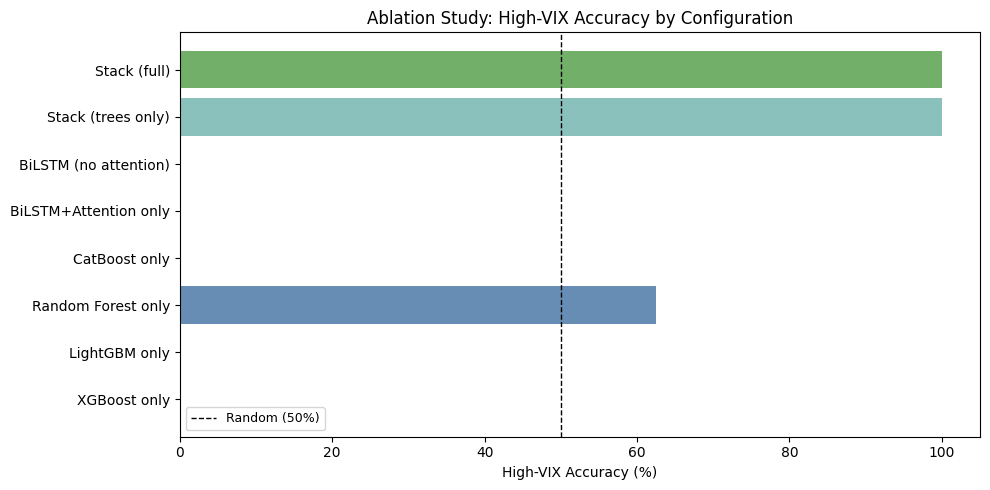

Plot saved.


In [7]:
# Plot High-VIX accuracy for each configuration
high_abl = abl_df[abl_df['Regime'] == 'High-VIX'][['Configuration', 'Accuracy (%)']]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4e79a7','#4e79a7','#4e79a7','#4e79a7','#e15759','#f28e2b','#76b7b2','#59a14f']
ax.barh(high_abl['Configuration'], high_abl['Accuracy (%)'], color=colors, alpha=0.85)
majority_baseline = abl_df[(abl_df['Regime'] == 'High-VIX') & (abl_df['Configuration'] == 'Stack (full)')]
ax.axvline(50, color='black', linestyle='--', linewidth=1, label='Random (50%)')
ax.set_xlabel('High-VIX Accuracy (%)')
ax.set_title('Ablation Study: High-VIX Accuracy by Configuration')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS / 'R08_ablation_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')